# Punto 3 — Optimización con restricciones: penalización

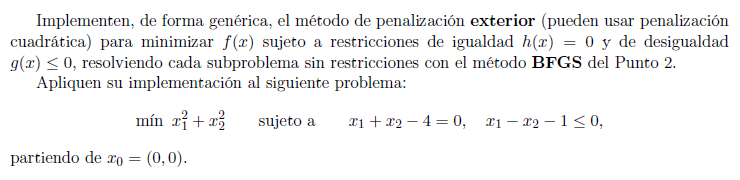

In [1]:
import numpy as np
from optimizadores import OptimizadorNoLineal

## Funciones

In [2]:
def f(x):
    """Función dada del problema."""
    x1, x2 = x
    return x1**2 + x2**2

def grad_f(x):
    "Gradiente de la función."
    x1, x2 = x
    return np.array([2*x1, 2*x2])

def h(x):
    """Restricciones de igualdad."""
    x1, x2 = x
    return x1 + x2 - 4

def grad_h(x):
    """Gradiente restricciones de igualdad."""
    return np.array([1.0, 1.0])   

def g(x):
    """Restricciones de desigualdad."""
    x1, x2 = x
    return x1 - x2 - 1

def grad_g(x):
    """Gradiente de las restricciones de desigualdad."""
    return np.array([1.0, -1.0]) 

def P(x, mu):
    """Función de penalización cuadrática exterior."""
    return f(x) + mu*(h(x)**2 + max(g(x), 0.0)**2)

def grad_P(x, mu):
    """Gradiente de la función de penalización."""
    return grad_f(x) + mu*(2*h(x)*grad_h(x) + 2*max(g(x), 0.0)*grad_g(x))

In [3]:
def penalizacion_exterior(f, grad_f, h, grad_h, g, grad_g, x0,
                           mu1=1.0, eta=10.0, eps=1e-6, max_ciclos=50):
    """
    Método de penalización exterior (cuadrática).
    """
    x_actual = x0.copy()
    mu = mu1
    historial_x = [x_actual.copy()]
    historial_mu = []

    for n in range(max_ciclos):
        def P_mu(x, mu=mu):
            return f(x) + mu*(h(x)**2 + max(g(x), 0.0)**2)

        def grad_P_mu(x, mu=mu):
            return grad_f(x) + mu*(2*h(x)*grad_h(x) + 2*max(g(x), 0.0)*grad_g(x))
            
        hist_x, hist_f, hist_gradnorm = OptimizadorNoLineal.optimizar(P_mu, grad_P_mu, x_actual, metodo='bfgs')
        x_nuevo = hist_x[-1]

        historial_x.append(x_nuevo.copy())
        historial_mu.append(mu)

        if np.linalg.norm(x_nuevo - x_actual) < eps:
            x_actual = x_nuevo
            break

        x_actual = x_nuevo
        mu *= eta

    return x_actual, np.array(historial_x), np.array(historial_mu)

## implementación

In [4]:
x0 = np.array([0.0, 0.0])
x_final, hist_x, hist_mu = penalizacion_exterior(f, grad_f, h, grad_h, g, grad_g, x0)

print(f'{"n":>4} {"mu_n":>12} {"x1":>10} {"x2":>10} {"h(x)":>10} {"g(x)":>10}')
for n in range(len(hist_mu)):
    x = hist_x[n+1]
    print(f'{n+1:>4} {hist_mu[n]:>12.1f} {x[0]:>10.5f} {x[1]:>10.5f} {h(x):>10.5f} {g(x):>10.5f}')

print()
print('x_final =', x_final)
print('f(x_final) =', f(x_final))

   n         mu_n         x1         x2       h(x)       g(x)
   1          1.0    1.33333    1.33333   -1.33333   -1.00000
   2         10.0    1.90476    1.90476   -0.19048   -1.00000
   3        100.0    1.99005    1.99005   -0.01990   -1.00000
   4       1000.0    1.99900    1.99900   -0.00200   -1.00000
   5      10000.0    1.99990    1.99990   -0.00020   -1.00000
   6     100000.0    1.99999    1.99999   -0.00002   -1.00000
   7    1000000.0    2.00000    2.00000   -0.00000   -1.00000
   8   10000000.0    2.00000    2.00000   -0.00000   -1.00000
   9  100000000.0    2.00000    2.00000   -0.00000   -1.00000

x_final = [1.99999999 1.99999999]
f(x_final) = 7.9999999200000005


De los resultados numéricos se observa que el método de penalización exterior converge correctamente hacia (2,2) con f≈8. A medida que μ_n crece (por un factor de 10 por ciclo), la restriccion de igualdad h(x) disminuye de forma proporcional. Por otro lado g(x) se mantiene constante todo el proceso, lo que confirma que la restriccion de desigualdad nunca estuvo activa.​
